In [46]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")

In [47]:
# Đọc dữ liệu từ file csv
merged_df = pd.read_csv("../DATA EXPLORER CONTEST/Preprocessed_Data/merged_data_(t-1).csv")

In [66]:
# --- Lấy các cột cần thiết ---
features = ['EPS','P/E','P/B','P/S',
            'Loi nhuan','Market Cap_lag1',
            'Foreign Investor Room_lag1','Remaining Room Shares_lag1']
target = 'Closing Price'

In [67]:
# Sắp xếp dữ liệu theo thời gian trước
merged_df = merged_df.sort_index()

# Tách thủ công theo thời gian: 80% train, 20% test
split_index = int(len(merged_df) * 0.8)
train_df = merged_df.iloc[:split_index]
test_df = merged_df.iloc[split_index:]

# Lấy X và y
X_train_raw = train_df[features]
y_train = train_df[target]

X_test_raw = test_df[features]
y_test = test_df[target]

# Lưu lại index (thời gian)
train_index = X_train_raw.index
test_index = X_test_raw.index



In [68]:
# --- Chuẩn hóa dữ liệu ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


In [69]:
# --- Xây mô hình ---
model = LinearRegression()
model.fit(X_train, y_train,)

# --- Dự đoán ---
y_pred = model.predict(X_test)

# --- Đánh giá mô hình ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error (MSE): 19195009.46
Root Mean Squared Error (RMSE): 4381.21
Mean Absolute Error (MAE): 3975.62
R² Score: -0.01


In [70]:
# Tạo DataFrame để dễ thao tác và sắp xếp
train_df = pd.DataFrame({'Giá huấn luyện': y_train}, index=train_index).sort_index()
test_df = pd.DataFrame({'Giá thực tế': y_test, 'Giá dự đoán': y_pred}, index=test_index).sort_index()



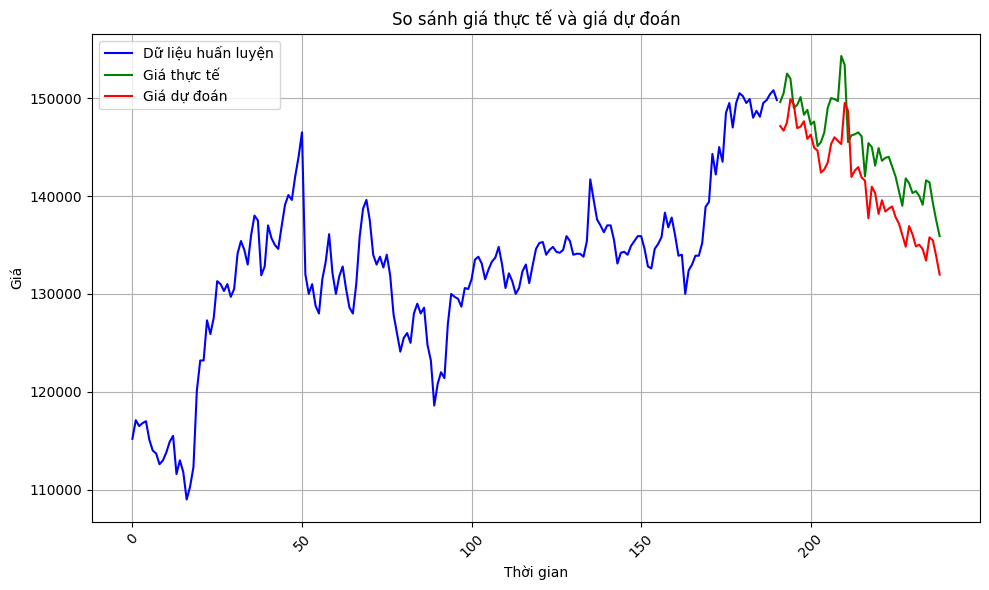

In [71]:
plt.figure(figsize=(10, 6))
plt.plot(train_df.index, train_df['Giá huấn luyện'], label='Dữ liệu huấn luyện', color='blue')
plt.plot(test_df.index, test_df['Giá thực tế'], label='Giá thực tế', color='green')
plt.plot(test_df.index, test_df['Giá dự đoán'], label='Giá dự đoán', color='red')

plt.legend()
plt.title('So sánh giá thực tế và giá dự đoán')
plt.xlabel('Thời gian')
plt.ylabel('Giá')
plt.grid(True)
plt.xticks(rotation=45)  # Xoay nhãn thời gian cho dễ đọc
plt.tight_layout()
plt.show()
